In [2]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt


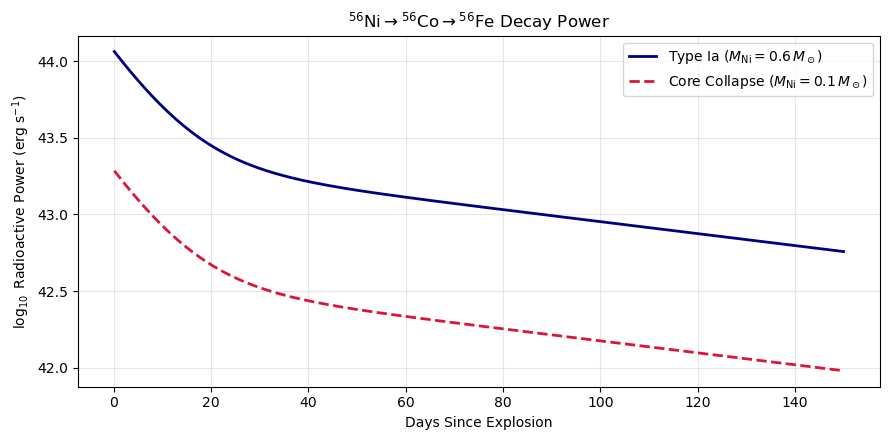

In [5]:
# -------------------------------------------------------------
# 1. Radioactive Decay Energy Deposition (Arnett Model)
# -------------------------------------------------------------
def radioactive_power(t_days, M_ni):
    """
    Computes energy deposition rate (erg/s) from 56Ni and 56Co decay.
    M_ni: Nickel mass in solar masses
    t_days: Time since explosion in days
    """
    t = np.maximum(t_days, 1e-5)
    
    # Decays and half-lives (Nadyozhin 1994)
    tau_ni = 8.8    # days
    tau_co = 111.3  # days
    
    eps_ni = 3.90e10 # erg/s/g
    eps_co = 6.78e9  # erg/s/g
    
    M_grams = M_ni * 1.989e33 # Change M_Ni and see the effect. 
    
    # Specific energy generation rates
    e_ni = eps_ni * np.exp(-t / tau_ni)
    e_co = eps_co * (np.exp(-t / tau_co) - np.exp(-t / tau_ni)) * (tau_co / (tau_co - tau_ni))
    
    return M_grams * (e_ni + e_co)

t_grid = np.linspace(0.1, 150, 500)
power_06 = radioactive_power(t_grid, M_ni=0.6) # Standard Type Ia
power_01 = radioactive_power(t_grid, M_ni=0.1) # Core collapse

plt.figure(figsize=(9, 4.5))
plt.plot(t_grid, np.log10(power_06), 'navy', lw=2, label=r'Type Ia ($M_{\mathrm{Ni}} = 0.6 \, M_\odot$)')
plt.plot(t_grid, np.log10(power_01), 'crimson', lw=2, linestyle='--', label=r'Core Collapse ($M_{\mathrm{Ni}} = 0.1 \, M_\odot$)')
plt.xlabel('Days Since Explosion')
plt.ylabel(r'$\log_{10}$ Radioactive Power ($\mathrm{erg \ s^{-1}}$)')
plt.title(r'$^{56}\mathrm{Ni} \rightarrow ^{56}\mathrm{Co} \rightarrow ^{56}\mathrm{Fe}$ Decay Power')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
/var/folders/gw/w6qdd1bn6zb2zrvd6dz7_9400000gp/T/ipykernel_91682/721568030.py:16: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Relative Accessible Survey Volume ($V / V_{\mathrm{max}}$)')


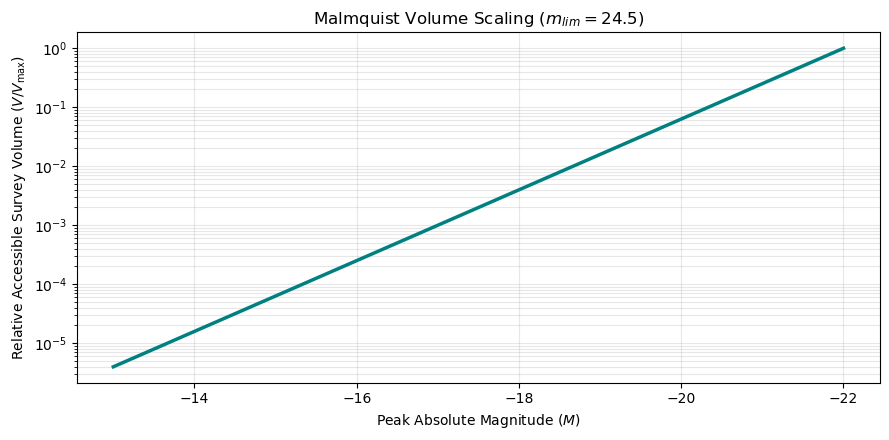

In [4]:


# -------------------------------------------------------------
# 2. Malmquist Bias Simulation (Accessible Survey Volume)
# -------------------------------------------------------------
m_lim = 24.5  # Rubin-like single visit magnitude limit
M_abs = np.linspace(-22, -13, 200)

# Volume scaling V proportional to 10^(0.6 * (m_lim - M))
log_vol = 0.6 * (m_lim - M_abs)
vol_relative = 10**(log_vol - np.max(log_vol)) # Normalized to peak

plt.figure(figsize=(9, 4.5))
plt.plot(M_abs, vol_relative, color='teal', lw=2.5)
plt.yscale('log')
plt.gca().invert_xaxis()
plt.xlabel('Peak Absolute Magnitude ($M$)')
plt.ylabel('Relative Accessible Survey Volume ($V / V_{\mathrm{max}}$)')
plt.title(f'Malmquist Volume Scaling ($m_{{lim}} = {m_lim}$)')
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()